# RQ3: Quali pattern ricorrenti caratterizzano i workflow CI/CD nei progetti AI-agent open source su GitHub? 
#### NB: controllare quanti falsi positivi rimangono nell'estrazione delle categorie

In [1]:
import pandas as pd
import random
random.seed(69)

DATASET_PATH = "C:\\dev\\SE4AI-base\\gigawork\\dataset_with_ids.csv"
BASE_GIGAWORK_PATH = "C:\\dev\\SE4AI-base\\gigawork\\all_workflows"

df = pd.read_csv(DATASET_PATH)

In [2]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))
from src.util.guess_file_type import classify_workflow

In [3]:
# carico i file hash univoci

df_unique = df.drop_duplicates(subset=['workflow_global_id'])

file_hash_by_repo = (
    df_unique.groupby('repository')['file_hash']
    .apply(list)
)

In [10]:
import yaml

result = {}

for repository_name in file_hash_by_repo.index:
    file_hashes = file_hash_by_repo[repository_name]
    repo_results = []
    for file_hash in file_hashes:
        workflow_path = Path(BASE_GIGAWORK_PATH) / repository_name / f"{file_hash}"
        if workflow_path.exists():
            try:
                with open(workflow_path, "r", encoding="utf-8") as f:
                    data = yaml.safe_load(f)

                out = classify_workflow(data)

                repo_results.append({
                    "file_hash": file_hash,
                    "wf_name": out.get("name"),
                    "labels": out.get("labels", []),
                    "matched_keywords": out.get("matched_keywords", {})
                })
            except Exception:
                continue

    result[repository_name] = repo_results

result

{'AntonOsika__gpt-engineer': [{'file_hash': '04e8eb65ebb244bfdce18f482301c4a5cc739cdcad2a9ebcc2859c84b1db70e1',
   'wf_name': 'Tox pytest all python versions',
   'labels': ['test'],
   'matched_keywords': {'lint': [],
    'test': ['pytest', '[name] test'],
    'build': [],
    'deploy': [],
    'security': [],
    'eval': [],
    'release': []}},
  {'file_hash': 'b49b58057bd39fccb7df78f7213d805bd534811a812b78b659219256fd74f513',
   'wf_name': 'Build and publish Python packages to PyPI',
   'labels': ['build', 'release'],
   'matched_keywords': {'lint': [],
    'test': [],
    'build': ['actions/upload-artifact', '[name] build', '[name] package'],
    'deploy': [],
    'security': [],
    'eval': [],
    'release': ['[name] publish']}},
  {'file_hash': '953a30775359908a4e420d0532b35d3c3517736afd745af591a8aa82e695ab36',
   'wf_name': 'Automation Workflow',
   'labels': ['unknown'],
   'matched_keywords': {'lint': [],
    'test': [],
    'build': [],
    'deploy': [],
    'security': [],

**è inutile analizzare i workflow con label unknown perchè sembrano rappresentare tutti workflow legati a github, quindi chiusura stale pr, commenti, etc etc.-- **

In [11]:
# conto quanti workflow file fanno soltanto una cosa e quanti invece fanno più cose (es. test + build) e quanti sono unknown

label_counts = {}

for repo, workflows in result.items():
    single, multi, unknown = 0, 0, 0
    for wf in workflows:
        labels = wf.get("labels", [])
        if len(labels) == 1:
            single += 1
        elif len(labels) > 1:
            multi += 1
        else:
            unknown += 1

    label_counts[repo] = {
        "single": single,
        "multi": multi,
        "unknown": unknown
    }

print(label_counts)


{'AntonOsika__gpt-engineer': {'single': 3, 'multi': 1, 'unknown': 0}, 'BloopAI__bloop': {'single': 3, 'multi': 5, 'unknown': 0}, 'Canner__WrenAI': {'single': 6, 'multi': 7, 'unknown': 0}, 'FOLLGAD__Godmode-GPT': {'single': 0, 'multi': 0, 'unknown': 0}, 'Farama-Foundation__chatarena': {'single': 6, 'multi': 1, 'unknown': 0}, 'FlowiseAI__Flowise': {'single': 3, 'multi': 3, 'unknown': 0}, 'HumanSignal__Adala': {'single': 20, 'multi': 2, 'unknown': 0}, 'Kav-K__GPTDiscord': {'single': 4, 'multi': 0, 'unknown': 0}, 'KillianLucas__open-interpreter': {'single': 1, 'multi': 1, 'unknown': 0}, 'MineDojo__Voyager': {'single': 1, 'multi': 0, 'unknown': 0}, 'Oneirocom__Magick': {'single': 4, 'multi': 1, 'unknown': 0}, 'OpenBMB__AgentVerse': {'single': 0, 'multi': 1, 'unknown': 0}, 'OpenBMB__ChatDev': {'single': 1, 'multi': 0, 'unknown': 0}, 'OpenDevin__OpenDevin': {'single': 11, 'multi': 8, 'unknown': 0}, 'OthersideAI__self-operating-computer': {'single': 1, 'multi': 0, 'unknown': 0}, 'PromtEngineer

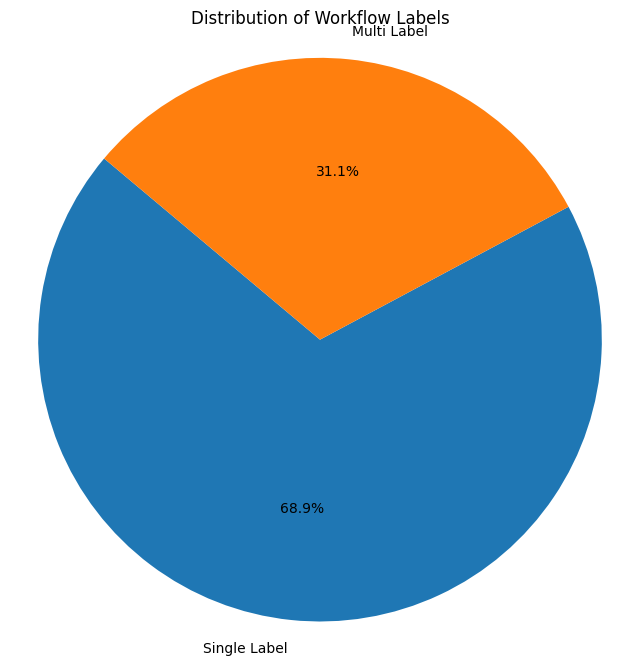

In [12]:
import matplotlib.pyplot as plt

# somma totale di single, multi e unknown
total_single = sum(counts["single"] for counts in label_counts.values())
total_multi = sum(counts["multi"] for counts in label_counts.values())
labels = ['Single Label', 'Multi Label']
sizes = [total_single, total_multi]
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Workflow Labels')
plt.axis('equal')
plt.show()


In [13]:
# quali sono le label piu comuni nei workflow multi-label? (es. test + build, test + deploy, ecc.) e quali sono le combinazioni di label piu comuni? (es. test + build, test + deploy, ecc.)

from collections import Counter
multi_label_combinations = Counter()
for repo, workflows in result.items():
    for wf in workflows:
        labels = wf.get("labels", [])
        if len(labels) > 1:
            multi_label_combinations[tuple(sorted(labels))] += 1
print(multi_label_combinations.most_common(10))

[(('build', 'release'), 34), (('build', 'test'), 26), (('lint', 'test'), 18), (('build', 'eval', 'test'), 11), (('build', 'deploy'), 8), (('build', 'lint', 'test'), 8), (('build', 'security'), 5), (('build', 'deploy', 'release'), 4), (('deploy', 'release'), 4), (('eval', 'test'), 3)]


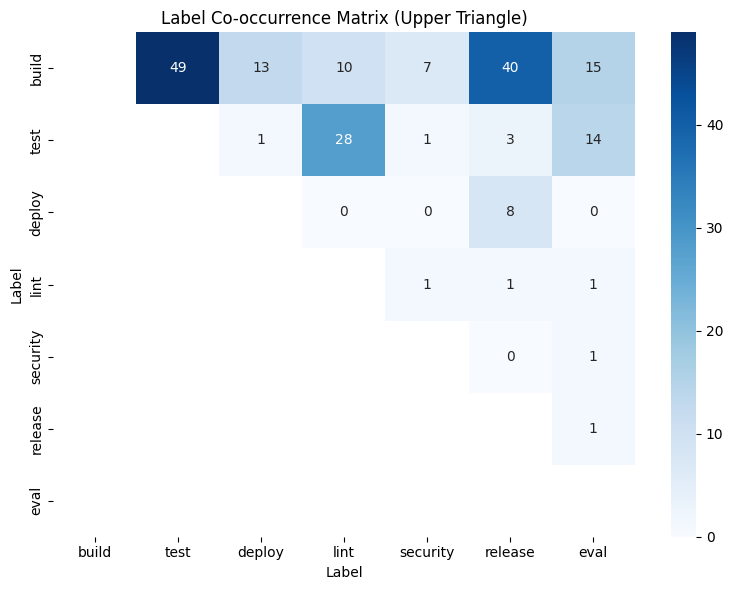

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_labels = ["build", "test", "deploy", "lint", "security", "release", "eval"]
matrix = pd.DataFrame(0, index=all_labels, columns=all_labels)

all_workflows = [wf for workflows in result.values() for wf in workflows]

for wf in all_workflows:
    labels = [l for l in wf.get("labels", []) if l in all_labels]
    for l1 in labels:
        for l2 in labels:
            if l1 != l2:
                matrix.loc[l1, l2] += 1

mask = np.tril(np.ones_like(matrix, dtype=bool), k=0)  # k=0 include diagonale

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", mask=mask)
plt.title("Label Co-occurrence Matrix (Upper Triangle)")
plt.xlabel("Label")
plt.ylabel("Label")
plt.tight_layout()
plt.show()


In [15]:
# le label single più comuni quali sono?
single_label_counts = Counter()
for repo, workflows in result.items():
    for wf in workflows:
        labels = wf.get("labels", [])
        if len(labels) == 1:
            single_label_counts[labels[0]] += 1
print(single_label_counts.most_common())


[('unknown', 119), ('test', 52), ('build', 36), ('release', 33), ('lint', 25), ('deploy', 14), ('security', 13), ('eval', 3)]
